# 02 - Exploratory Data Analysis

This notebook explores the two cleaned datasets produced in `01_Data_Ingestion_And_Cleaning.ipynb`.  
The goal is to understand the distributions, identify patterns by route and nationality, and get a feel for where anomalies might concentrate — before running any detection model.

**Datasets used:**
- `viaggiatori_clean.csv` — one row per traveler check, with demographics and control outcome
- `allarmi_clean.csv` — aggregated alarm counts by route, date and occurrence type

**Structure:**
1. Setup & load
2. TIPOLOGIA_VIAGGIATORE — univariate distributions
3. ALLARMI — volume and alarm breakdown by route and month
4. Cross-dataset — alarm rate by nationality and origin country

In [42]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [43]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('project_anomaly_detection')

v = pd.read_csv(DATA_DIR / 'viaggiatori_clean.csv')
a = pd.read_csv(DATA_DIR / 'allarmi_clean.csv', parse_dates=['DATA_PARTENZA'])

print('viaggiatori:', v.shape)
print('allarmi:    ', a.shape)

viaggiatori: (5095, 28)
allarmi:     (5080, 19)


## 1. TIPOLOGIA_VIAGGIATORE

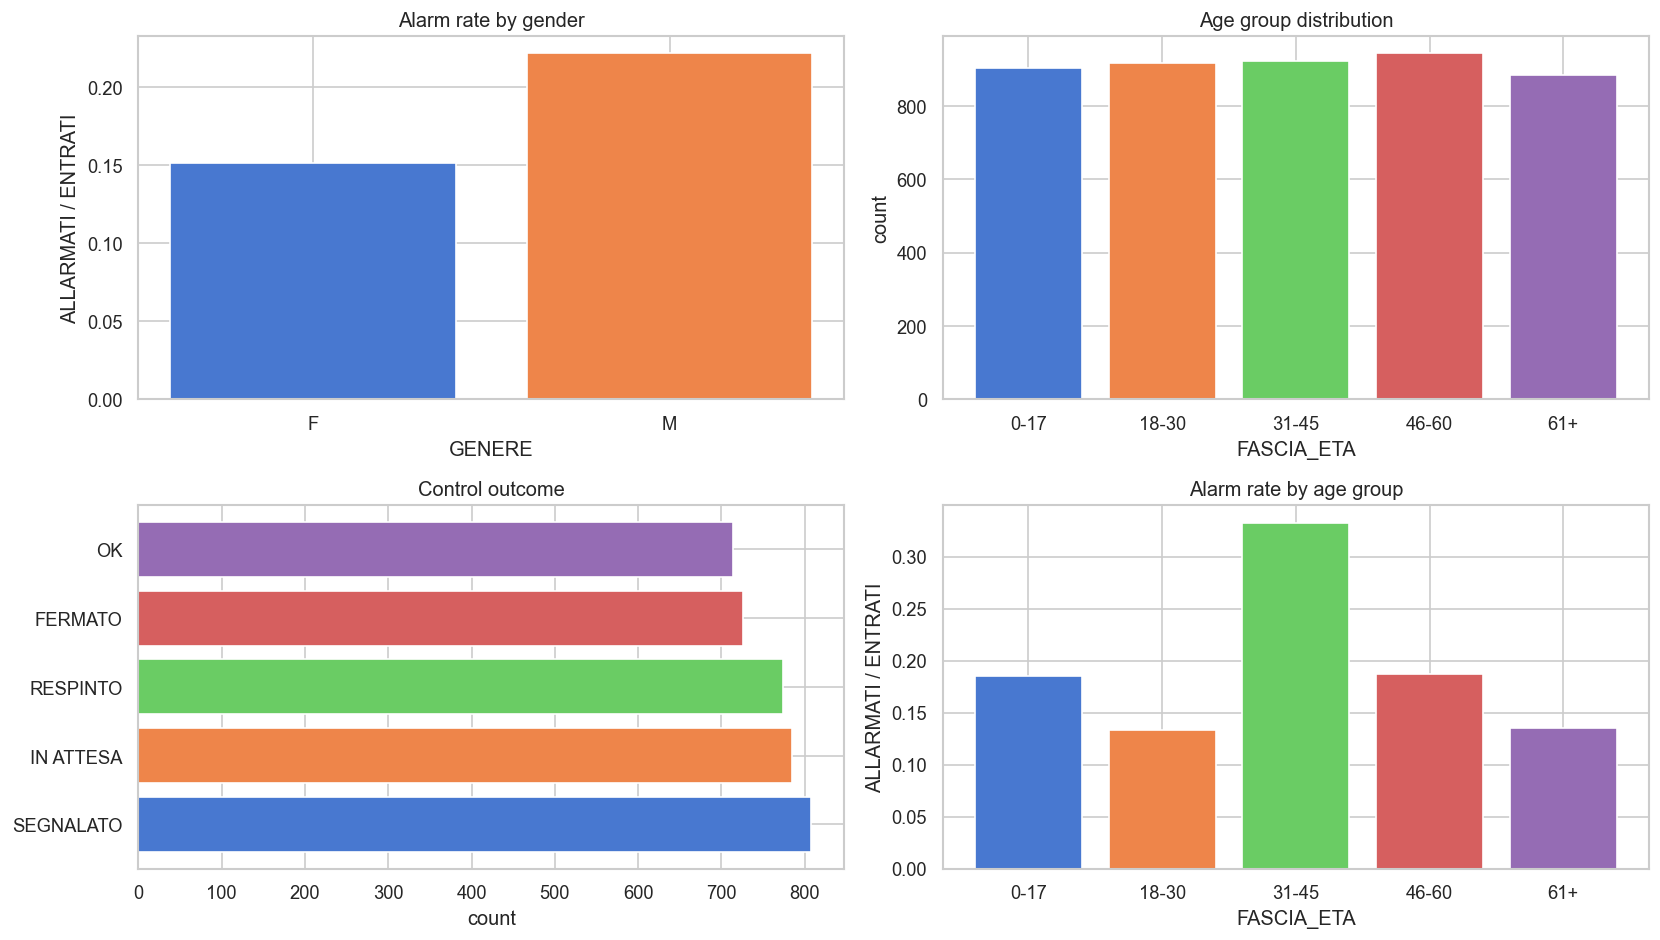

In [44]:
# distributions and alarm rates for key categorical columns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# alarm rate by gender
genere_stats = v.groupby('GENERE')[['ENTRATI', 'ALLARMATI']].sum()
genere_stats['alarm_rate'] = genere_stats['ALLARMATI'] / genere_stats['ENTRATI']
axes[0, 0].bar(genere_stats.index, genere_stats['alarm_rate'], color=sns.color_palette('muted'))
axes[0, 0].set_title('Alarm rate by gender')
axes[0, 0].set_xlabel('GENERE')
axes[0, 0].set_ylabel('ALLARMATI / ENTRATI')

# FASCIA_ETA — explicit order so it's always chronological
age_order = ['0-17', '18-30', '31-45', '46-60', '61+']
eta = v['FASCIA_ETA'].value_counts(dropna=True).reindex(age_order, fill_value=0)
axes[0, 1].bar(eta.index, eta.values, color=sns.color_palette('muted'))
axes[0, 1].set_title('Age group distribution')
axes[0, 1].set_xlabel('FASCIA_ETA')
axes[0, 1].set_ylabel('count')

# ESITO_CONTROLLO
esito = v['ESITO_CONTROLLO'].value_counts(dropna=True)
axes[1, 0].barh(esito.index.astype(str), esito.values, color=sns.color_palette('muted'))
axes[1, 0].set_title('Control outcome')
axes[1, 0].set_xlabel('count')

# alarm rate by age group
age_stats = v.groupby('FASCIA_ETA')[['ENTRATI', 'ALLARMATI']].sum()
age_stats = age_stats.reindex(age_order).dropna()
age_stats['alarm_rate'] = age_stats['ALLARMATI'] / age_stats['ENTRATI']
axes[1, 1].bar(age_stats.index, age_stats['alarm_rate'], color=sns.color_palette('muted'))
axes[1, 1].set_title('Alarm rate by age group')
axes[1, 1].set_xlabel('FASCIA_ETA')
axes[1, 1].set_ylabel('ALLARMATI / ENTRATI')

plt.tight_layout()
plt.show()

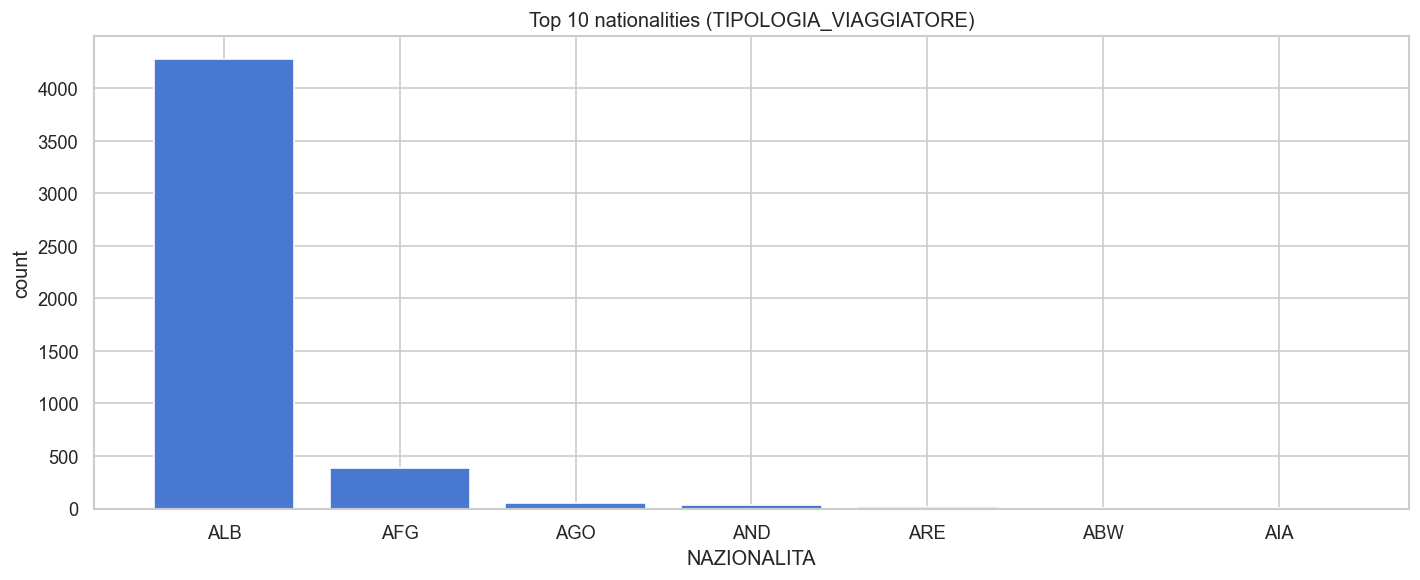

In [45]:
# top 10 nationalities
top_naz = v['NAZIONALITA'].value_counts(dropna=True).head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_naz.index, top_naz.values)
plt.title('Top 10 nationalities (TIPOLOGIA_VIAGGIATORE)')
plt.xlabel('NAZIONALITA')
plt.ylabel('count')
plt.tight_layout()
plt.show()

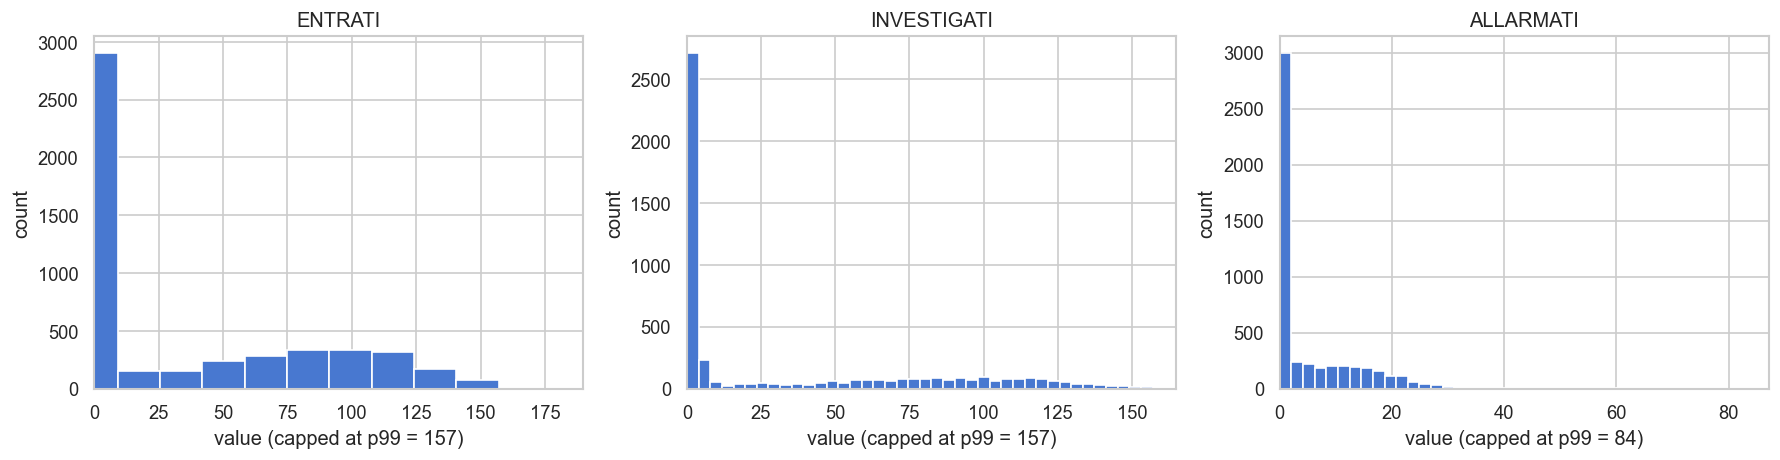

In [46]:
# numeric columns: ENTRATI, INVESTIGATI, ALLARMATI
# cap at 99th percentile to avoid outliers collapsing the visible range
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']):
    data = v[col].dropna()
    cap = data.quantile(0.99)
    ax.hist(data[data <= cap], bins=40, edgecolor='white')
    ax.set_xlim(left=0)
    ax.set_title(col)
    ax.set_xlabel(f'value (capped at p99 = {cap:.0f})')
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

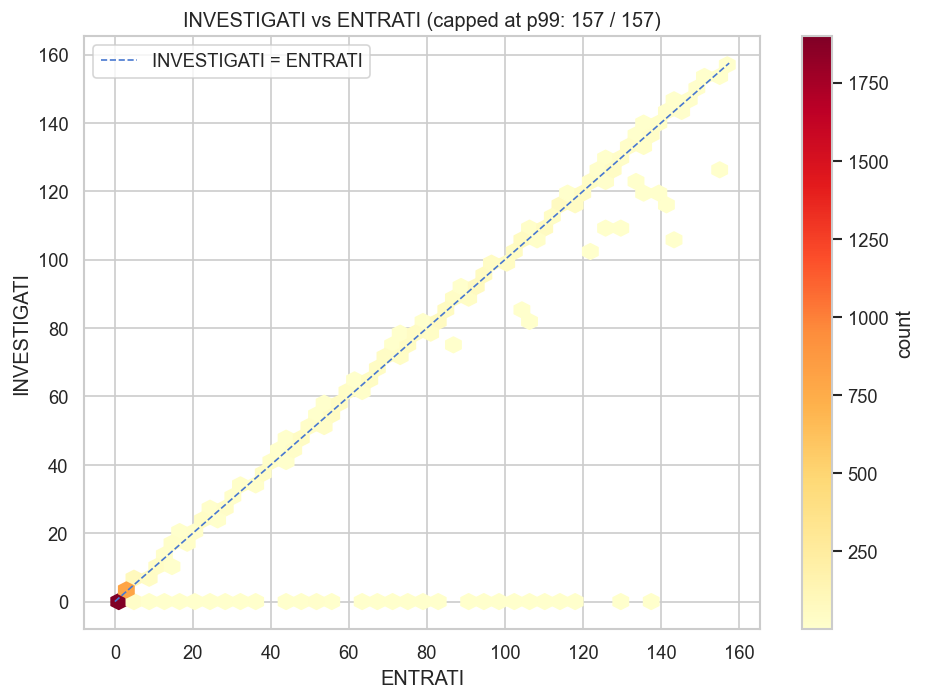

In [47]:
# INVESTIGATI vs ENTRATI — hexbin shows density, outliers visible outside the main cluster
scatter_df = v[['ENTRATI', 'INVESTIGATI']].dropna()
scatter_df = scatter_df[(scatter_df['ENTRATI'] > 0) & (scatter_df['INVESTIGATI'] >= 0)]

cap_e = scatter_df['ENTRATI'].quantile(0.99)
cap_i = scatter_df['INVESTIGATI'].quantile(0.99)
scatter_df = scatter_df[(scatter_df['ENTRATI'] <= cap_e) & (scatter_df['INVESTIGATI'] <= cap_i)]

fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(scatter_df['ENTRATI'], scatter_df['INVESTIGATI'],
               gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='count')
ax.plot([0, cap_e], [0, cap_e], 'b--', linewidth=1, label='INVESTIGATI = ENTRATI')
ax.set_title(f'INVESTIGATI vs ENTRATI (capped at p99: {cap_e:.0f} / {cap_i:.0f})')
ax.set_xlabel('ENTRATI')
ax.set_ylabel('INVESTIGATI')
ax.legend()
plt.tight_layout()
plt.show()

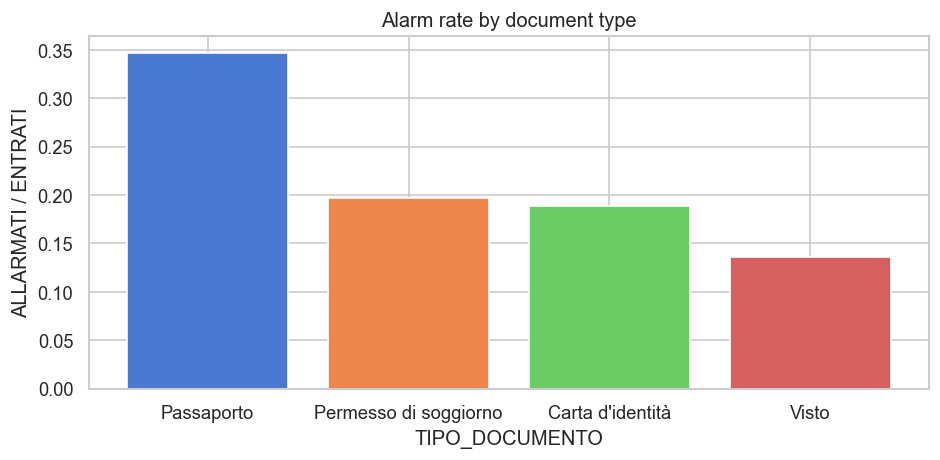

In [48]:
# alarm rate by document type
doc_stats = v.groupby('TIPO_DOCUMENTO')[['ENTRATI', 'ALLARMATI']].sum()
doc_stats['alarm_rate'] = doc_stats['ALLARMATI'] / doc_stats['ENTRATI']
doc_stats = doc_stats.sort_values('alarm_rate', ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(doc_stats.index, doc_stats['alarm_rate'], color=sns.color_palette('muted'))
plt.title('Alarm rate by document type')
plt.xlabel('TIPO_DOCUMENTO')
plt.ylabel('ALLARMATI / ENTRATI')
plt.tight_layout()
plt.show()

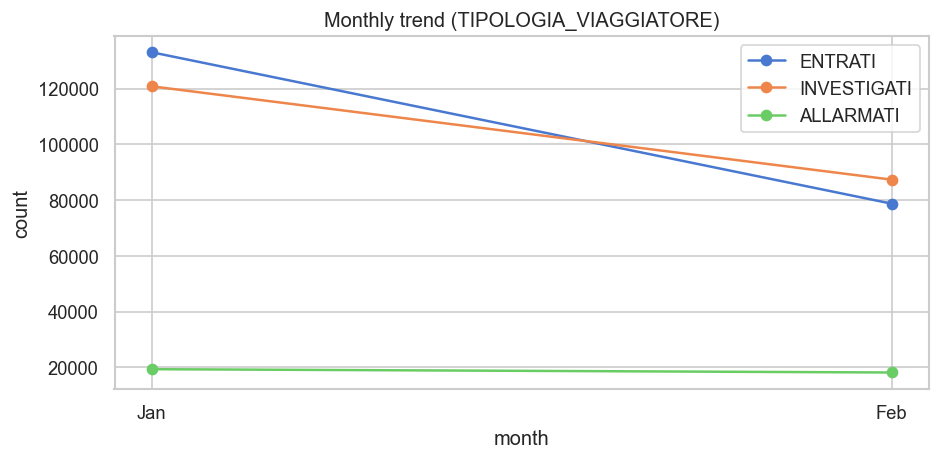

In [49]:
# monthly trend — exclude month 12 (data entry errors from rows with wrong year)
month_stats = v[v['MESE_PARTENZA'] != 12].groupby('MESE_PARTENZA')[['ENTRATI', 'INVESTIGATI', 'ALLARMATI']].sum()
month_labels = {1: 'Jan', 2: 'Feb'}
month_stats.index = month_stats.index.map(lambda x: month_labels.get(int(x), str(x)))

plt.figure(figsize=(8, 4))
for col in ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']:
    plt.plot(month_stats.index, month_stats[col], marker='o', label=col)
plt.title('Monthly trend (TIPOLOGIA_VIAGGIATORE)')
plt.xlabel('month')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

## 2. ALLARMI

In [50]:
# pivot OCCORRENZE so each type becomes its own column
allarmi_pivot = a.pivot_table(
    index=['AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'MESE_PARTENZA'],
    columns='OCCORRENZE',
    values='TOT',
    aggfunc='sum'
).reset_index()

allarmi_pivot.columns.name = None
print(allarmi_pivot.shape)
allarmi_pivot.head()

(820, 30)


,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,MESE_PARTENZA,Allarmi Chiusi,Allarmi Chiusi con Azione (CC.xx),Allarmi NON Chiusi,Allarmi Rilevanti,Allarmi generati,Allarmi generati da BCS,Allarmi generati da INTERPOL,...,Nulla a procedere NSIS,Nulla a procedere SDI,Respinto/a,Viaggiatori con Allarmi,Viaggiatori entrati nel Sistema,Viaggiatori investigati,Voli con Allarmi,Voli disponibili in ingresso al Sistema,Voli investigati (SDI/NSIS - INTERPOL - TSC),"Voli solo visualizzati, ma NON investigati"
0,AOI,STN,1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0,NaN
1,AOI,STN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,AOI,TIA,1,NaN,NaN,NaN,21.0,NaN,NaN,NaN,...,NaN,28.0,NaN,42.0,138.0,123.0,NaN,1.0,2.0,1.0
3,AOI,TIA,2,37.0,NaN,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,209.0,NaN,NaN,1.0,2.0,NaN
4,AOI,TIA,6,NaN,NaN,NaN,16.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


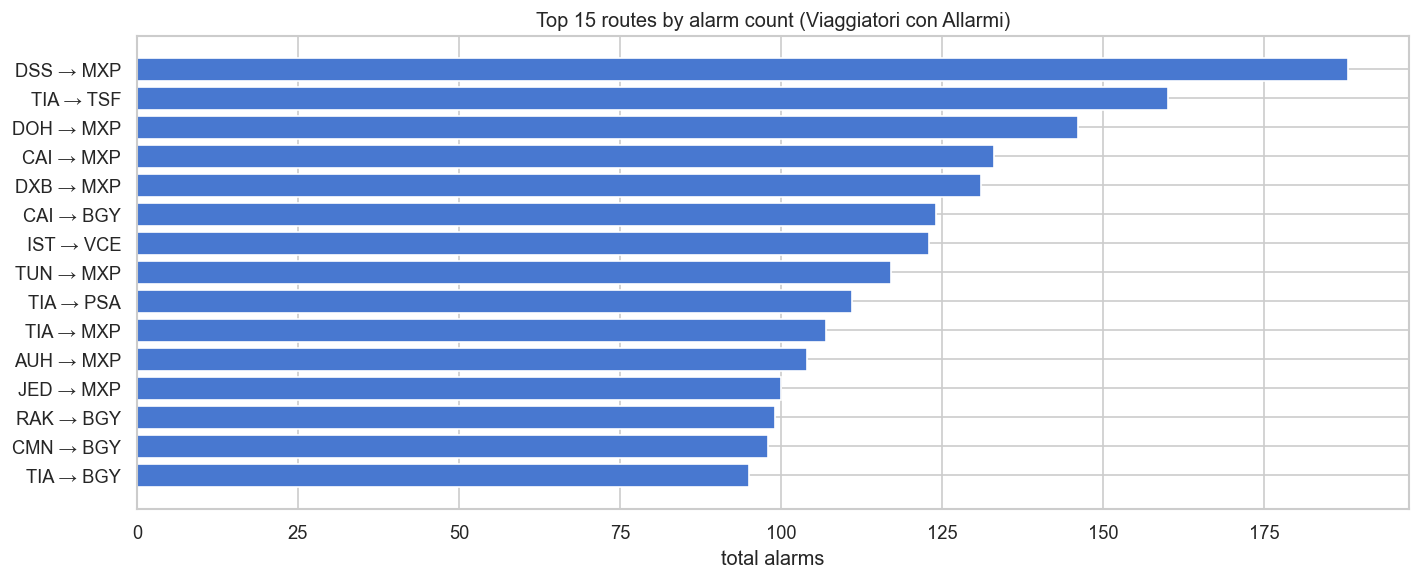

In [51]:
# top 15 routes by total alarms
route_alarms = a[a['OCCORRENZE'] == 'Viaggiatori con Allarmi'].groupby(
    ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO'])['TOT'].sum().sort_values(ascending=False).head(15)

route_alarms.index = [f"{p} → {ar}" for p, ar in route_alarms.index]

plt.figure(figsize=(12, 5))
plt.barh(route_alarms.index[::-1], route_alarms.values[::-1])
plt.title('Top 15 routes by alarm count (Viaggiatori con Allarmi)')
plt.xlabel('total alarms')
plt.tight_layout()
plt.show()

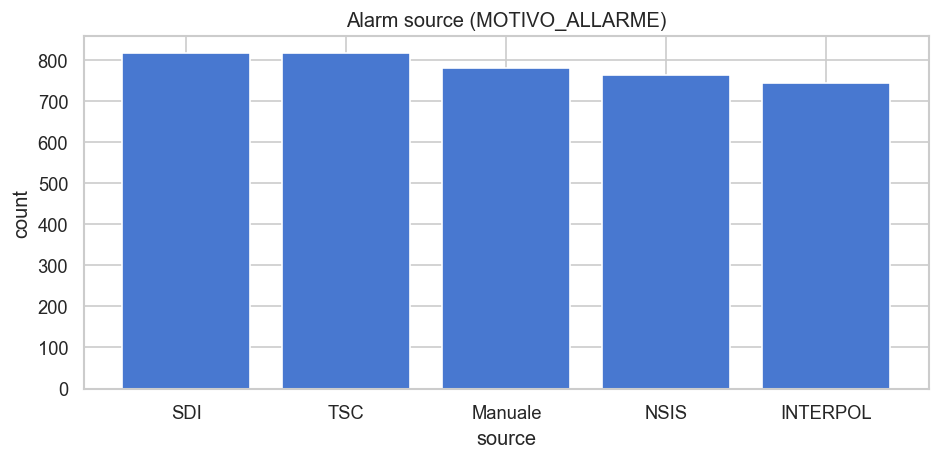

In [52]:
# alarm breakdown by MOTIVO_ALLARME
motivo = a['MOTIVO_ALLARME'].value_counts(dropna=True)

plt.figure(figsize=(8, 4))
plt.bar(motivo.index, motivo.values)
plt.title('Alarm source (MOTIVO_ALLARME)')
plt.xlabel('source')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## 3. Cross-dataset — alarm rate by origin country

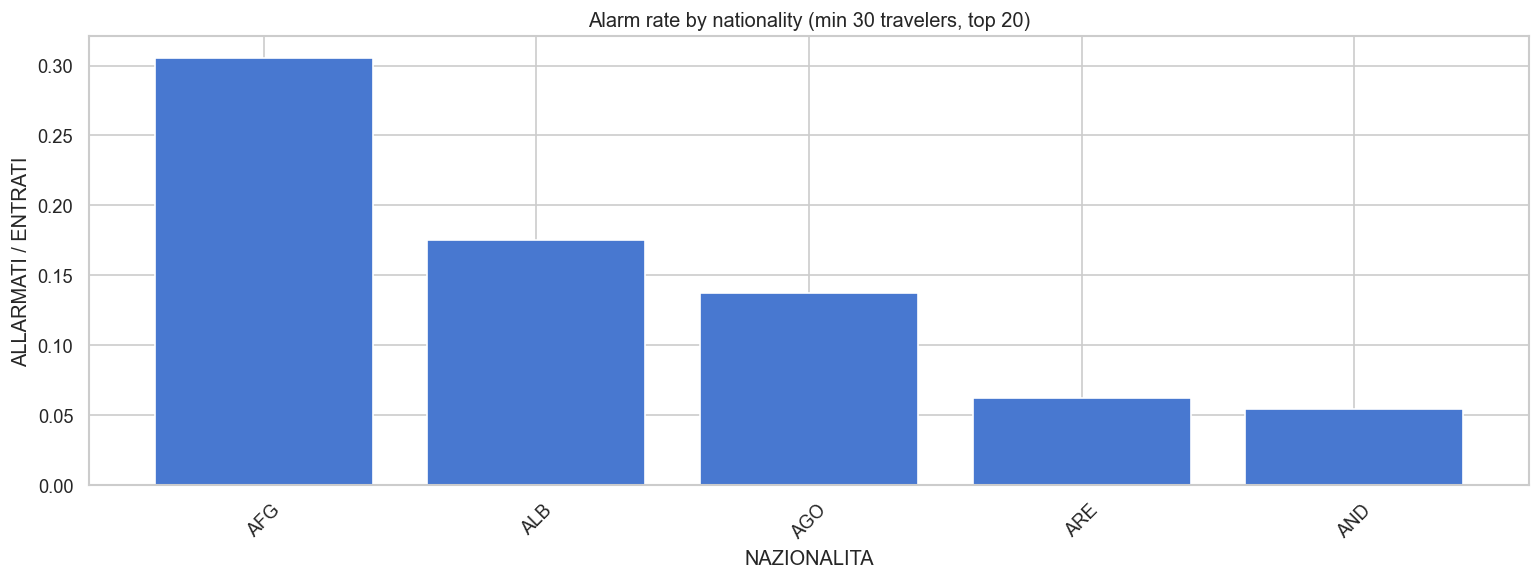

In [53]:
# alarm rate per nationality: ALLARMATI / ENTRATI
# only where we have enough records to be meaningful (min 30 travelers)
nat_stats = v.groupby('NAZIONALITA').agg(
    entrati=('ENTRATI', 'sum'),
    allarmati=('ALLARMATI', 'sum')
).dropna()

nat_stats = nat_stats[nat_stats['entrati'] >= 30].copy()
nat_stats['alarm_rate'] = nat_stats['allarmati'] / nat_stats['entrati']
nat_stats = nat_stats.sort_values('alarm_rate', ascending=False).head(20)

plt.figure(figsize=(13, 5))
plt.bar(nat_stats.index, nat_stats['alarm_rate'])
plt.title('Alarm rate by nationality (min 30 travelers, top 20)')
plt.xlabel('NAZIONALITA')
plt.ylabel('ALLARMATI / ENTRATI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()